In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('diabetic_data.csv').replace("?", pd.NA)

In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.info()
df.head()
df.duplicated().sum()
df.isna().sum().sort_values(ascending=False).head(30)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [8]:
def to_binary(x):
    if pd.isna(x): return pd.NA
    s = str(x).strip().lower()
    if s == "<30": return 1
    if s in ("no", ">30"): return 0
    return pd.NA

df['readmitted_binary'] = df['readmitted'].apply(to_binary)
df['readmitted_binary'].value_counts(dropna=False)


,count
readmitted_binary,
0,90409
1,11357


In [9]:
df = df.drop_duplicates().copy()
# drop columns with >80% missing
thresh = 0.8 * len(df)
to_drop = df.columns[df.isna().sum() > thresh].tolist()
df = df.drop(columns=to_drop)



In [10]:
num_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications','number_diagnoses']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# convert age group to numeric representative (midpoint)
def age_mid(s):
    s = str(s)
    if '[' in s and '-' in s:
        a,b = s.strip('[]()').split('-')
        return (int(a)+int(b))/2
    return pd.NA

if 'age' in df.columns:
    df['age_mid'] = df['age'].apply(age_mid)


<Axes: xlabel='readmitted_binary', ylabel='count'>

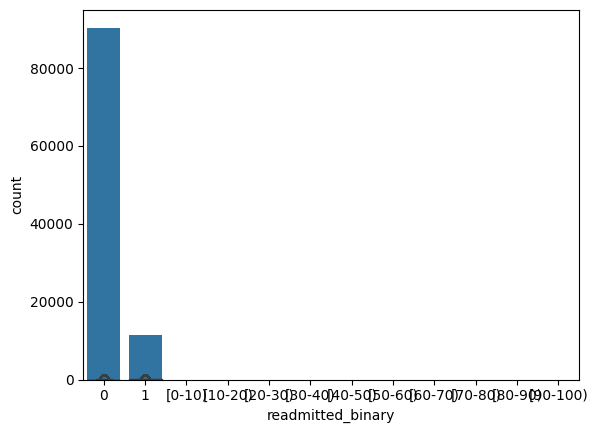

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='readmitted_binary')
sns.barplot(data=df.groupby('age')['readmitted_binary'].mean().reset_index(), x='age', y='readmitted_binary')
sns.boxplot(data=df, x='readmitted_binary', y='num_medications')


In [12]:
df['polypharmacy'] = (df['num_medications'] > 10).astype(int)
# diag bucket example (coarse)
def diag_bucket(val):
    if pd.isna(val): return 'unknown'
    s = str(val).upper()
    import re
    m = re.match(r'\d+', s)
    if m:
        code = int(m.group(0))
        if 250 <= code < 251: return 'diabetes'
        if 390 <= code <= 459: return 'circulatory'
        # ... add others
    if s.startswith('V') or s.startswith('E'): return 'external'
    return 'other'
for c in ['diag_1','diag_2','diag_3']:
    if c in df.columns:
        df[c+'_bucket'] = df[c].apply(diag_bucket)
df['any_diabetes_diag'] = df[[c+'_bucket' for c in ['diag_1','diag_2','diag_3'] if c+'_bucket' in df.columns]].apply(lambda r: int('diabetes' in r.values), axis=1)


In [14]:
feature_cols = [
    'age_mid', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses', 'polypharmacy',
    'any_diabetes_diag'
]

df = df.dropna(subset=['readmitted_binary']).copy()


print("Target distribution:\n", df['readmitted_binary'].value_counts())

X = df[feature_cols]
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Train/test sizes:", X_train.shape, X_test.shape)

Target distribution:
 readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
Train/test sizes: (81412, 7) (20354, 7)


📘 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20354
   macro avg       0.44      0.50      0.47     20354
weighted avg       0.79      0.89      0.84     20354

ROC AUC: 0.5730965144747081
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🌲 Random Forest Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     18083
           1       0.12      0.03      0.05      2271

    accuracy                           0.86     20354
   macro avg       0.51      0.50      0.49     20354
weighted avg       0.80      0.86      0.83     20354

ROC AUC: 0.5176033293127806
F1 Score: 0.054165238258484745


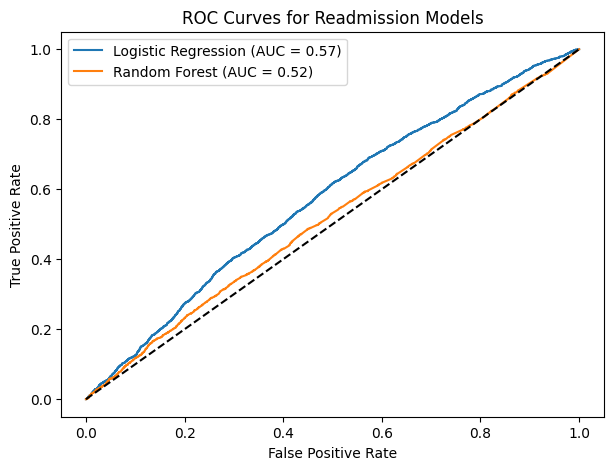

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, f1_score, roc_curve
)
import matplotlib.pyplot as plt

# --- 1 Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(" Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# --- 2 Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# ---  Compare ROC Curves ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Readmission Models')
plt.legend()
plt.show()

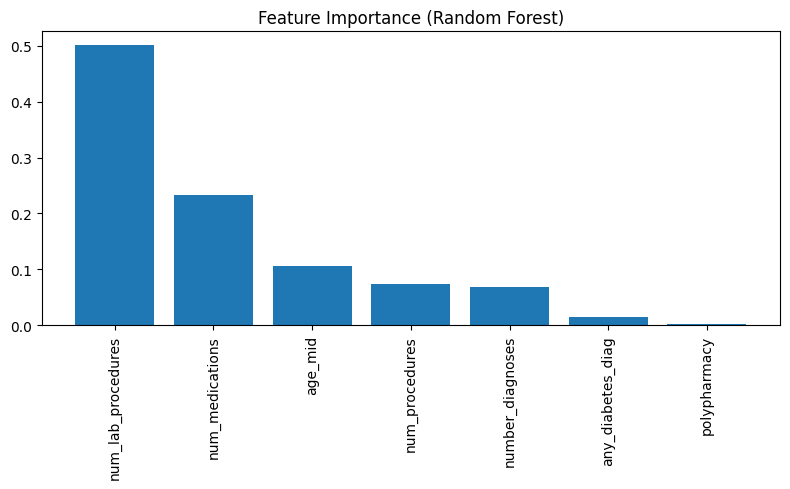


🔹 Logistic Regression Coefficients:
              Feature  Coefficient
5        polypharmacy     0.129985
6   any_diabetes_diag     0.115052
4    number_diagnoses     0.075688
3     num_medications     0.010394
0             age_mid     0.000993
1  num_lab_procedures     0.000837
2      num_procedures    -0.047714


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Feature Importance (Random Forest) ---
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# --- Logistic Regression Coefficients ---
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n🔹 Logistic Regression Coefficients:")
print(coef_df.head(10))


In [ ]:
from sklearn.model_selection import GridSearchCV

# Random Forest Tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(grid_rf.best_params_)
print("Best F1 Score:", grid_rf.best_score_)

# Logistic Regression Tuning
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("\nBest Logistic Regression Parameters:")
print(grid_lr.best_params_)
print("Best F1 Score:", grid_lr.best_score_)


In [ ]:
# Retrain best models with tuned hyperparameters
best_rf = grid_rf.best_estimator_
best_lr = grid_lr.best_estimator_

# Fit on training data
best_rf.fit(X_train, y_train)
best_lr.fit(X_train, y_train)

# Predict
y_pred_rf_best = best_rf.predict(X_test)
y_pred_lr_best = best_lr.predict(X_test)

# Probabilities for ROC
y_proba_rf_best = best_rf.predict_proba(X_test)[:, 1]
y_proba_lr_best = best_lr.predict_proba(X_test)[:, 1]

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve
import matplotlib.pyplot as plt

print("Logistic Regression (Tuned) Results:")
print(classification_report(y_test, y_pred_lr_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr_best))
print("F1 Score:", f1_score(y_test, y_pred_lr_best))

print("\nRandom Forest (Tuned) Results:")
print(classification_report(y_test, y_pred_rf_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf_best))
print("F1 Score:", f1_score(y_test, y_pred_rf_best))

# ROC Curve comparison
fpr_lr_best, tpr_lr_best, _ = roc_curve(y_test, y_proba_lr_best)
fpr_rf_best, tpr_rf_best, _ = roc_curve(y_test, y_proba_rf_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr_best, tpr_lr_best, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr_best):.2f})')
plt.plot(fpr_rf_best, tpr_rf_best, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf_best):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned Models')
plt.legend()
plt.show()


In [ ]:
import shap

# Initialize SHAP explainer for the best random forest model
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Summary Plot (Feature Importance Visualization)
shap.summary_plot(shap_values[1], X_test, plot_type="bar")

# Detailed summary plot showing how each feature affects predictions
shap.summary_plot(shap_values[1], X_test)

# Dependence plot for a specific key feature (example: 'num_medications')
if 'num_medications' in X_test.columns:
    shap.dependence_plot('num_medications', shap_values[1], X_test)


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

# Define age bins (adjust as per your dataset's age format)
age_bins = {
    '[0-10)': (0, 10),
    '[10-20)': (10, 20),
    '[20-30)': (20, 30),
    '[30-40)': (30, 40),
    '[40-50)': (40, 50),
    '[50-60)': (50, 60),
    '[60-70)': (60, 70),
    '[70-80)': (70, 80),
    '[80-90)': (80, 90),
    '[90-100)': (90, 100)
}

results = []

# Ensure the age column is numeric or mapped from categorical
# Example if your age is like "[40-50)" strings:
if X_test['age'].dtype == 'object':
    def extract_age_range(a):
        try:
            return int(a.strip('[]()').split('-')[0])
        except:
            return np.nan
    age_numeric = X_test['age'].apply(extract_age_range)
else:
    age_numeric = X_test['age']

# Evaluate model performance by age group
for label, (low, high) in age_bins.items():
    mask = (age_numeric >= low) & (age_numeric < high)
    if mask.sum() < 10:  # skip very small groups
        continue
    y_true_sub = y_test[mask]
    y_pred_sub = best_rf.predict(X_test[mask])
    y_proba_sub = best_rf.predict_proba(X_test[mask])[:, 1]
    results.append({
        'Age Group': label,
        'Count': mask.sum(),
        'F1 Score': f1_score(y_true_sub, y_pred_sub),
        'ROC AUC': roc_auc_score(y_true_sub, y_proba_sub)
    })

# Display results
age_perf = pd.DataFrame(results)
print(age_perf)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(age_perf['Age Group'], age_perf['F1 Score'], marker='o', label='F1 Score')
plt.plot(age_perf['Age Group'], age_perf['ROC AUC'], marker='s', label='ROC AUC')
plt.xticks(rotation=45)
plt.xlabel('


In [ ]:

# Select 5 random patients from test data
random_idx = np.random.choice(X_test.index, size=5, replace=False)
sample = X_test.loc[random_idx]

# Predict using your best model (replace best_rf with your final model variable)
predictions = best_rf.predict(sample)
probabilities = best_rf.predict_proba(sample)[:, 1]

# Combine for display
results = sample.copy()
results['Predicted_Readmission'] = np.where(predictions == 1, 'Yes (<30 days)', 'No')
results['Readmission_Probability'] = probabilities.round(3)

# Show results
pd.set_option('display.max_columns', None)
results.head(5)
